In [15]:
# Cell 1: Setup
import data_loader
import importlib
importlib.reload(data_loader)

# Setup
from data_loader import *
import matplotlib.pyplot as plt
import numpy as np


print("BOX_SIZE2:", BOX_SIZE)
plt.rcParams.update({'font.size': 14})


Loading bubble data...
✓ Loaded 139446 observations
✓ Timesteps added: 0 to 725
✓ Identified 300 disappearing bubbles
Applying periodic boundary corrections...
✓ Periodic boundary correction applied
✓ Derived quantities computed

DATA LOADING COMPLETE
Total observations:       139,446
Unique bubbles:           400
Timesteps:                0 to 725
Disappearing bubbles:     300
Box size:                 20.203051
Initial avg area (A_0):   1.000000

Available variables:
  - df: Original dataframe
  - df_corrected: Corrected dataframe with actual_area column
  - disappearing_ids: Set of disappearing bubble IDs
  - bubbles_per_timestep: Number of bubbles at each timestep
  - avg_area_per_timestep: Average bubble area at each timestep
  - approx_avg_area: Approximate area from liquid fraction
  - A_0: Initial average bubble area
  - max_timestep: Maximum timestep
  - final_step: Final timestep
  - box_area: Total box area
  - BOX_SIZE, PERIODIC_THRESHOLD, LIQUID_FRACTION: Constants

BOX_SI

In [16]:
dt_values = [1, 5, 20, 100, 400, 700]

# Make globally positive coordinates for x and y
min_x = df_corrected["x"].min()
min_y = df_corrected["y"].min()


offset_x = 1.0 - min_x   # ensures min Sx ≈ 1
offset_y = 1.0 - min_y


df_corrected["Sx"] = df_corrected["x"] + offset_x
df_corrected["Sy"] = df_corrected["y"] + offset_y

In [17]:
def get_signed_logreturns_bubbles(dt):
    """Return pooled signed log-returns r_x, r_y for all bubbles at lag dt."""
    log_ret_x, log_ret_y = [], []

    for bubble_id, g in df_corrected.groupby("id"):
        g = g.sort_values("timestep").copy()
        Sx = g["Sx"].to_numpy()
        Sy = g["Sy"].to_numpy()

        if len(Sx) <= dt:
            continue

        r_x = np.log(Sx[dt:] / Sx[:-dt])
        r_y = np.log(Sy[dt:] / Sy[:-dt])

        log_ret_x.extend(r_x)
        log_ret_y.extend(r_y)

    all_r = np.sqrt(np.array(log_ret_x)**2 + np.array(log_ret_y)**2)
    all_r = all_r - all_r.mean()     # recentre (should be ~0 anyway)
    return all_r 

Δt=1: n=139046, mean=1.62885e-19, var=1.07025e-05
Δt=5: n=137446, mean=-3.03715e-19, var=9.62676e-05
Δt=20: n=131568, mean=8.16837e-19, var=4.02450e-04
Δt=100: n=105293, mean=4.31888e-18, var=1.59060e-03
Δt=400: n=41573, mean=-4.70015e-19, var=5.33665e-03
Δt=700: n=2671, mean=-3.99032e-18, var=1.43819e-02


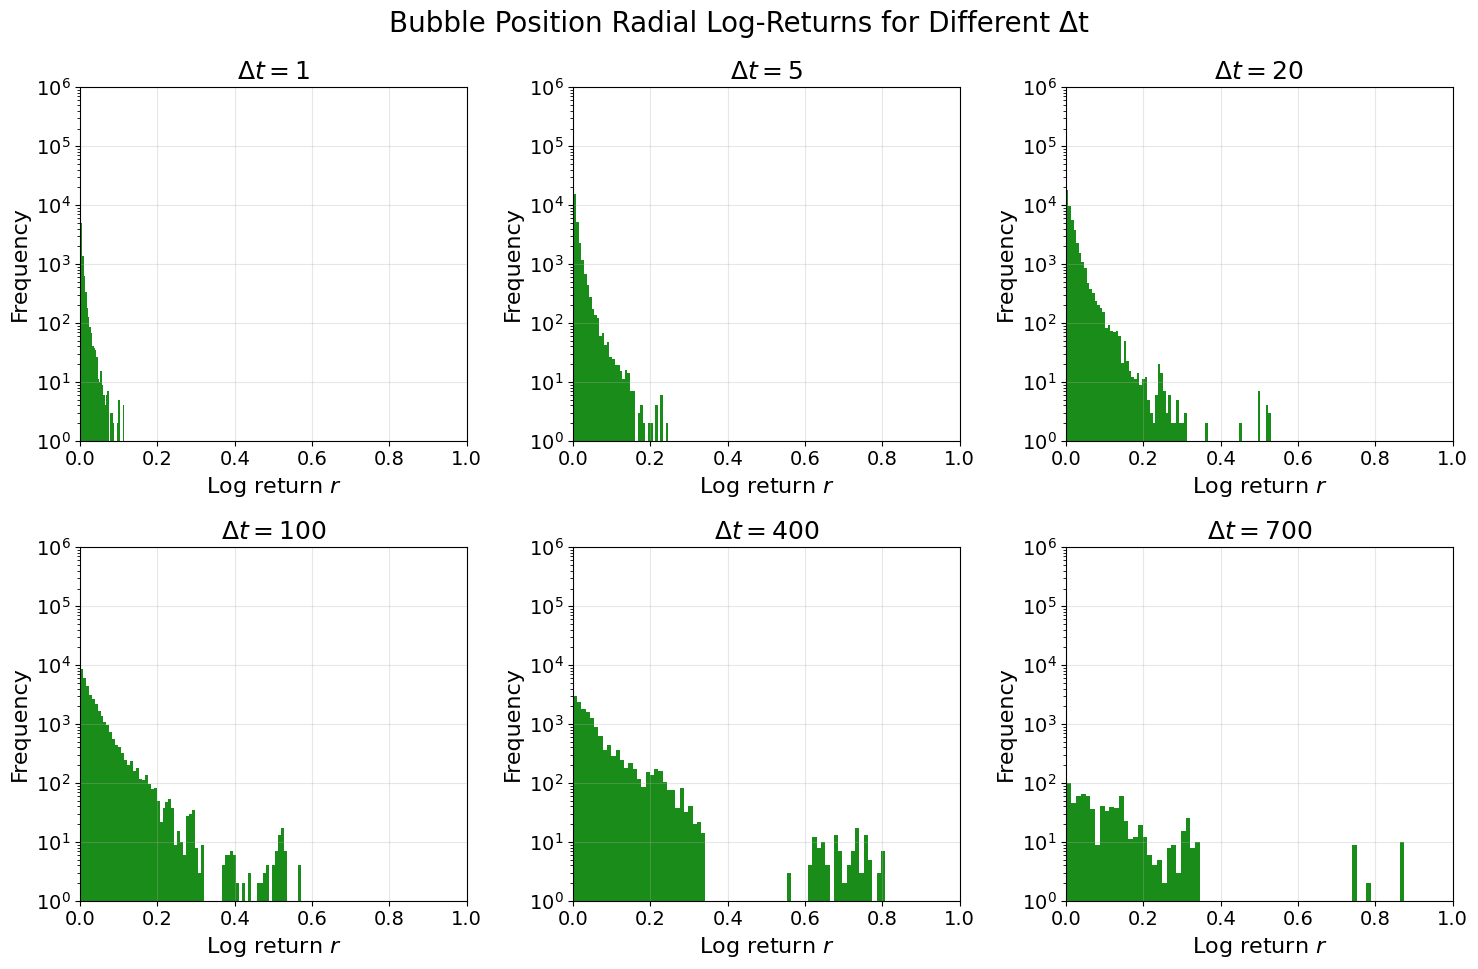

In [18]:
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs = axs.ravel()
plt.suptitle('Bubble Position Radial Log-Returns for Different Δt', fontsize=20, y=0.97)

for idx, dt in enumerate(dt_values):
    all_r = get_signed_logreturns_bubbles(dt)
    if all_r.size == 0:
        continue

    axs[idx].hist(all_r, bins=80, alpha=0.9, color='green')
    axs[idx].set_title(rf"$\Delta t = {dt}$", fontsize=18)
    axs[idx].grid(alpha=0.3)
    axs[idx].set_yscale('log')
    axs[idx].set_xlim(0, 1)
    axs[idx].set_ylim(1, 1e6)
    axs[idx].set_xlabel(r"Log return $r$", fontsize=16)
    axs[idx].set_ylabel("Frequency", fontsize=16)

    mean_r, var_r = np.mean(all_r), np.var(all_r)
    print(f"Δt={dt}: n={len(all_r)}, mean={mean_r:.5e}, var={var_r:.5e}")

plt.tight_layout(rect=[0, 0, 1, 0.99])
#plt.savefig("/Users/conorkirby/Library/Mobile Documents/com~apple~CloudDocs/Coding/projects/python/capstone/Figures/09.5_Figures/log_returns_radial_dt_values.png", dpi=300, bbox_inches='tight')
plt.show()

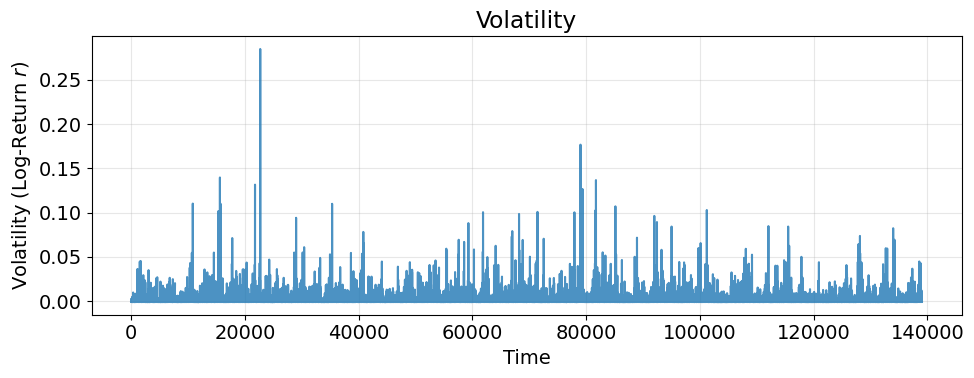

In [19]:
# Make globally positive coordinates for x and y
min_x = df_corrected["x"].min()
min_y = df_corrected["y"].min()


offset_x = 1.0 - min_x   # ensures min Sx ≈ 1
offset_y = 1.0 - min_y


df_corrected["Sx"] = df_corrected["x"] + offset_x
df_corrected["Sy"] = df_corrected["y"] + offset_y



# Function to get signed log-returns
def get_signed_logreturns_bubbles(dt):
    """Return pooled signed log-returns r_x, r_y for all bubbles at lag dt."""
    log_ret_x, log_ret_y = [], []

    for bubble_id, g in df_corrected.groupby("id"):
        g = g.sort_values("timestep").copy()
        Sx = g["Sx"].to_numpy()
        Sy = g["Sy"].to_numpy()

        if len(Sx) <= dt:
            continue

        r_x = np.log(Sx[dt:] / Sx[:-dt])
        r_y = np.log(Sy[dt:] / Sy[:-dt])

        log_ret_x.extend(r_x)
        log_ret_y.extend(r_y)

    

    log_ret = np.sqrt(np.array(log_ret_x)**2 + np.array(log_ret_y)**2)
    log_ret = log_ret - log_ret.mean()     # recentre (should be ~0 anyway)
    return log_ret 

# Get log-returns for dt=1    
log_ret = get_signed_logreturns_bubbles(dt=1)
time = np.arange(len(log_ret))

# Plot Log-Returns over Time
plt.figure(figsize=(10,4))
plt.plot(time, log_ret, alpha=0.8)
plt.xlabel("Time")
plt.ylabel("Volatility (Log-Return $r$)")
plt.title("Volatility")
plt.grid(alpha=0.3)
plt.tight_layout()
#plt.savefig("/Users/conorkirby/Library/Mobile Documents/com~apple~CloudDocs/Coding/projects/python/capstone/Figures_Sample2/10_Figures/volatility_2.png", dpi=300, bbox_inches='tight')






log-return correlation time τ_c ≈ 6.73 frames


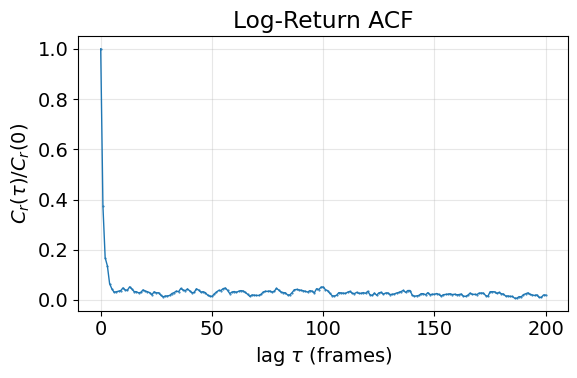

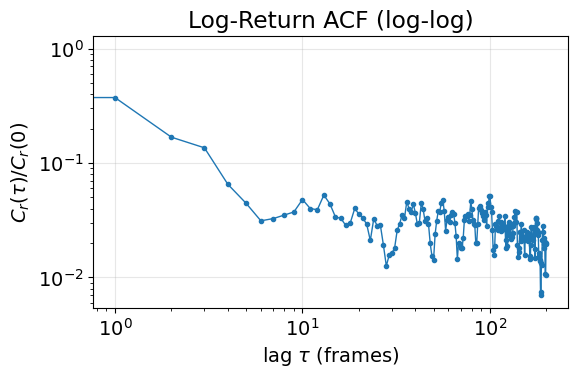

In [20]:
# --- helpers copied from 09 ---
def scalar_acf_fft(x, max_lag=None):
    x = np.asarray(x, dtype=float)
    n = len(x)
    if max_lag is None or max_lag > n - 1:
        max_lag = n - 1
    x = x - np.mean(x)
    nfft = 1 << (2 * n - 1).bit_length()
    f = np.fft.rfft(x, n=nfft)
    p = f * np.conjugate(f)
    acf = np.fft.irfft(p, n=nfft)[:n]
    norm = np.arange(n, 0, -1, dtype=float)
    acf = acf / norm
    return acf[:max_lag + 1]

def correlation_time(lags, C_norm, stop_at_zero_cross=True):
    lags = np.asarray(lags)
    C_norm = np.asarray(C_norm)
    if stop_at_zero_cross:
        mask = np.where(C_norm[1:] <= 0)[0]
        if len(mask) > 0:
            cut = mask[0] + 1
            lags = lags[:cut]
            C_norm = C_norm[:cut]
    return np.trapezoid(C_norm, lags)

# --- choose the log-return series to analyse ---
dt_for_acf = 1                # set the Δt you want
all_r = get_signed_logreturns_bubbles(dt_for_acf)   # or reuse existing all_r

# --- compute ACF on log returns ---
max_lag = min(200, len(all_r) - 1)
C = scalar_acf_fft(all_r, max_lag=max_lag)
C_norm = C / C[0]
lags = np.arange(max_lag + 1)
tau_c_r = correlation_time(lags, C_norm)

print(f"log-return correlation time τ_c ≈ {tau_c_r:.2f} frames")

plt.figure(figsize=(6,4))
plt.plot(lags, C_norm, marker='o', ms=0.5, lw=1)
plt.xlabel(r"lag $\tau$ (frames)")
plt.ylabel(r"$C_r(\tau)/C_r(0)$")
plt.title(f"Log-Return ACF")
plt.grid(alpha=0.3)
plt.tight_layout()
#plt.savefig("/Users/conorkirby/Library/Mobile Documents/com~apple~CloudDocs/Coding/projects/python/capstone/Figures/09.5_Figures/logreturn_acf_dt1.png", dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(6,4))
plt.loglog(lags, C_norm, marker='o', ms=3, lw=1)
plt.xlabel(r"lag $\tau$ (frames)")
plt.ylabel(r"$C_r(\tau)/C_r(0)$")
plt.title(f"Log-Return ACF (log-log)")
plt.grid(alpha=0.3)
plt.tight_layout()
#plt.savefig("/Users/conorkirby/Library/Mobile Documents/com~apple~CloudDocs/Coding/projects/python/capstone/Figures/09.5_Figures/logreturn_acf_dt1_loglog.png", dpi=300, bbox_inches='tight')
plt.show()


Δt=1: log-return correlation time τ_c ≈ 6.73 frames
Δt=2: log-return correlation time τ_c ≈ 9.43 frames
Δt=5: log-return correlation time τ_c ≈ 15.39 frames
Δt=25: log-return correlation time τ_c ≈ 37.26 frames
Δt=50: log-return correlation time τ_c ≈ 49.31 frames
Δt=100: log-return correlation time τ_c ≈ 64.33 frames
Δt=200: log-return correlation time τ_c ≈ 86.65 frames
Δt=300: log-return correlation time τ_c ≈ 92.68 frames


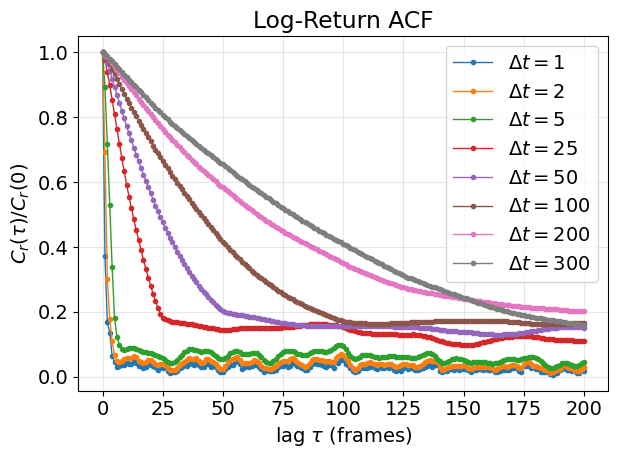

In [21]:
dt_for_acf = [1, 2, 5, 25, 50, 100, 200, 300]                # set the Δt you want

for dt in dt_for_acf:
    all_r = get_signed_logreturns_bubbles(dt)   # or reuse existing all_r

    # --- compute ACF on log returns ---
    max_lag = min(200, len(all_r) - 1)
    C = scalar_acf_fft(all_r, max_lag=max_lag)
    C_norm = C / C[0]
    lags = np.arange(max_lag + 1)
    tau_c_r = correlation_time(lags, C_norm)

    print(f"Δt={dt}: log-return correlation time τ_c ≈ {tau_c_r:.2f} frames")

    plt.plot(lags, C_norm, marker='o', ms=3, lw=1, label=rf'$\Delta t = {dt}$')
    plt.xlabel(r"lag $\tau$ (frames)")
    plt.ylabel(r"$C_r(\tau)/C_r(0)$")
    plt.title(f"Log-Return ACF")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.legend()

#plt.savefig("/Users/conorkirby/Library/Mobile Documents/com~apple~CloudDocs/Coding/projects/python/capstone/Figures/09.5_Figures/logreturn_acf_multiple_dt.png", dpi=300, bbox_inches='tight')  
plt.show()